# Machine Learning in Applications project

# Before starting...

## Clone GithHub repo

In [36]:
import os

if not os.path.exists("/content/mla-prj-23-project-am04_group-am01") and not os.path.exists("/content/mla_project"):
  # DON'T SHARE THE PERSONAL ACCESS TOKEN

  # change the name of the branch here as needed
  !git clone -b metrics https://***REMOVED-GITHUB-TOKEN***@github.com/MLinApp-polito/mla-prj-23-project-am04_group-am01.git

  # Rename folder for simplicity
  !mv /content/mla-prj-23-project-am04_group-am01 /content/mla_project

!cd /content/mla_project && git pull

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 411 bytes | 411.00 KiB/s, done.
From https://github.com/MLinApp-polito/mla-prj-23-project-am04_group-am01
   bcd899c..ab67a5c  metrics    -> origin/metrics
Updating bcd899c..ab67a5c
Fast-forward
 metrics/gen_train_gen_test.py | 2 +-
 1 file changed, 1 insertion(+), 1 deletion(-)


## Install Dependencies

In [7]:
!pip install torch torchvision matplotlib tqdm lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.9 MB/s eta 0:00:00


## Imports

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Classifier on Original dataset

## Dataset mean and std

In [ ]:
!python /content/mla_project/src/data_loader.py --data-dir /content/mla_project/images/original --compute-stats

Dataset mean (grayscale): 0.5839
Dataset std (grayscale): 0.2074


## Training - no augmentation

**IMPORTANT:**

- To perform K-Fold cross-validation, set --is_kfold to "True" and specify the number of folds with --k-folds. Example: --is_kfold "True", --k-folds 5

- To perform a single train/val split, set --is_kfold to "False" and specify the validation split ratio with --val-split. Example: --is_kfold "False", --val-split 0.2

- In both cases, to perform also testing, set --test to "True" and specify the test split ratio with --test-split. Example: --test "True", --test-split 0.2

### Define paths and parameters

In [ ]:
data_dir = '/content/mla_project/images/original'

# Training params
batch_size = 2
epochs = 10
learning_rate = 1e-5
backbone = 'resnet18'
device = 'cuda' if __import__('torch').cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


### Launch training

In [ ]:
# k-fold cross validation (with test)

!python /content/mla_project/src/train.py \
    --data-dir "{data_dir}" \
    --batch-size {batch_size} \
    --epochs {10} \
    --lr {learning_rate} \
    --backbone {backbone} \
    --num-workers 2 \
    --pretrained "False" \
    --is_kfold "False" \
    --val-split 0.2 \
    --test "True" \
    --test-split 0.2

Training with single train/val split
Using device: cuda

 Loading data...

Data loaded!

Train samples: 48, Validation samples: 16

Using resnet18 as backbone
No pretrained weights

Model loaded!
Traceback (most recent call last):
object address  : 0x78cfe05ea740
object refcount : 2
object type     : 0x9d5ea0
object type name: KeyboardInterrupt
object repr     : KeyboardInterrupt()
lost sys.stderr


### Plot Training & Validation Curves

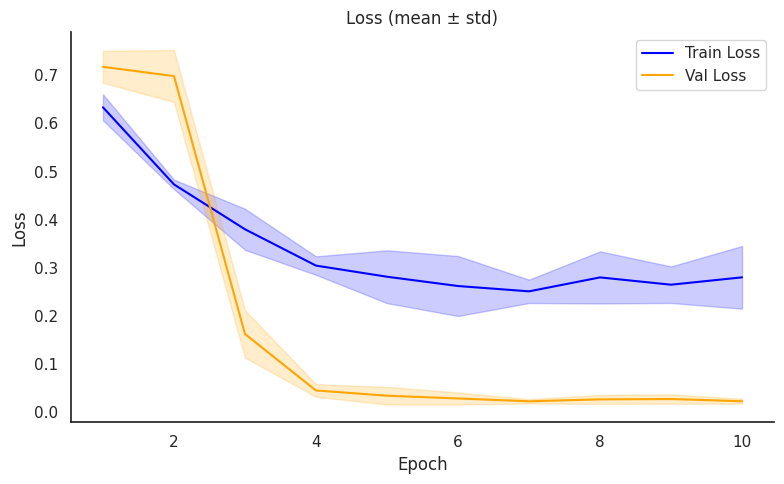

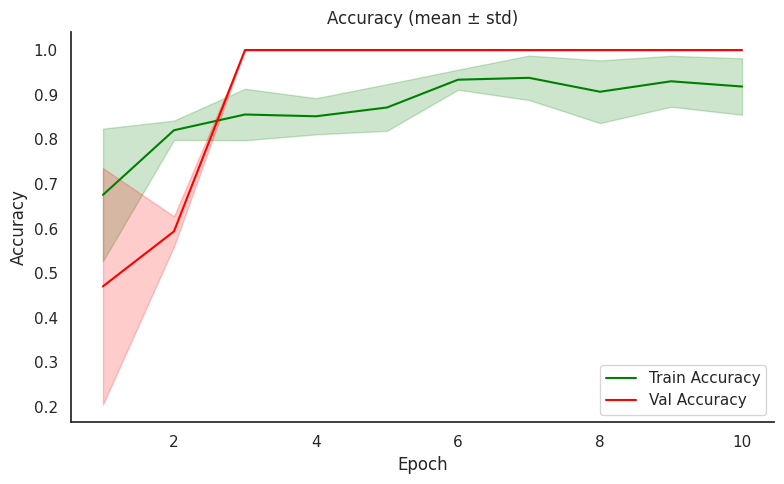

In [ ]:
# plot for cross-validation
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read logs
logs = pd.read_csv('/content/kfold_logs.csv')

# Group for epoch and get mean and std
grouped = logs.groupby('epoch').agg({
    'train_loss': ['mean', 'std'],
    'val_loss': ['mean', 'std'],
    'train_acc': ['mean', 'std'],
    'val_acc': ['mean', 'std']
}).reset_index()

# Rename columns
grouped.columns = ['epoch',
                   'train_loss_mean', 'train_loss_std',
                   'val_loss_mean', 'val_loss_std',
                   'train_acc_mean', 'train_acc_std',
                   'val_acc_mean', 'val_acc_std']

# Set style
sns.set(style="white", context="notebook")

# LOSS
plt.figure(figsize=(8, 5))
plt.plot(grouped['epoch'], grouped['train_loss_mean'], label='Train Loss', color='blue')
plt.fill_between(grouped['epoch'],
                 grouped['train_loss_mean'] - grouped['train_loss_std'],
                 grouped['train_loss_mean'] + grouped['train_loss_std'],
                 color='blue', alpha=0.2)

plt.plot(grouped['epoch'], grouped['val_loss_mean'], label='Val Loss', color='orange')
plt.fill_between(grouped['epoch'],
                 grouped['val_loss_mean'] - grouped['val_loss_std'],
                 grouped['val_loss_mean'] + grouped['val_loss_std'],
                 color='orange', alpha=0.2)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss (mean ± std)')
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

# ACCURACY
plt.figure(figsize=(8, 5))
plt.plot(grouped['epoch'], grouped['train_acc_mean'], label='Train Accuracy', color='green')
plt.fill_between(grouped['epoch'],
                 grouped['train_acc_mean'] - grouped['train_acc_std'],
                 grouped['train_acc_mean'] + grouped['train_acc_std'],
                 color='green', alpha=0.2)

plt.plot(grouped['epoch'], grouped['val_acc_mean'], label='Val Accuracy', color='red')
plt.fill_between(grouped['epoch'],
                 grouped['val_acc_mean'] - grouped['val_acc_std'],
                 grouped['val_acc_mean'] + grouped['val_acc_std'],
                 color='red', alpha=0.2)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy (mean ± std)')
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()


## Training - basic augmentations (simple transformations)

In [ ]:
data_dir = '/content/mla_project/images/original'

# Training params
batch_size = 2
epochs = 10
learning_rate = 1e-5
backbone = 'resnet50'
device = 'cuda' if __import__('torch').cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# k-fold cross validation (with test) with augmented data

!python /content/mla_project/src/train.py \
    --data-dir "{data_dir}" \
    --batch-size {batch_size} \
    --epochs {10} \
    --lr {learning_rate} \
    --backbone {backbone} \
    --num-workers 2 \
    --is_kfold "True" \
    --k-folds 5 \
    --test "True" \
    --test-split 0.2 \
    --aug "True"

Training with K-Fold cross-validation
Using device: cuda

===== Fold 1 =====

[Fold 1] Number of training images: 51
[Fold 1] Number of validation images: 13
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
[Fold 1] Epoch 1/10 | Train Loss: 0.6131, Acc: 0.6863 | Val Loss: 0.7186, Acc: 0.6154, Precision: 0.3787, Recall: 0.6154, F1: 0.4689
[Fold 1] Epoch 2/10 | Train Loss: 0.5093, Acc: 0.7647 | Val Loss: 0.4691, Acc: 0.6154, Precision: 0.3787, Recall: 0.6154, F1: 0.4689
[Fold 1] Epoch 3/10 | Train Loss: 0.3813, Acc: 0.8824 | Val Loss: 0.0829, Acc: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
[Fold 1] Epoch 4/10 | Train Loss: 0.3267

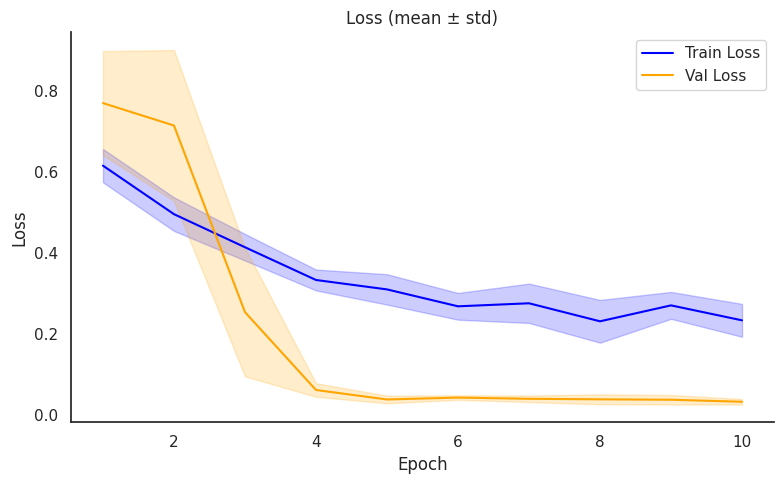

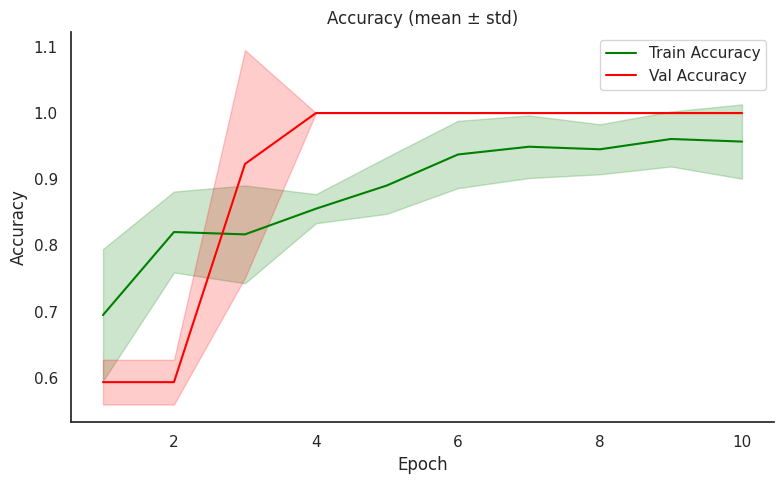

In [ ]:
# plot for cross-validation
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read logs
logs = pd.read_csv('/content/kfold_logs.csv')

# Group for epoch and get mean and std
grouped = logs.groupby('epoch').agg({
    'train_loss': ['mean', 'std'],
    'val_loss': ['mean', 'std'],
    'train_acc': ['mean', 'std'],
    'val_acc': ['mean', 'std']
}).reset_index()

# Rename columns
grouped.columns = ['epoch',
                   'train_loss_mean', 'train_loss_std',
                   'val_loss_mean', 'val_loss_std',
                   'train_acc_mean', 'train_acc_std',
                   'val_acc_mean', 'val_acc_std']

# Set style
sns.set(style="white", context="notebook")

# LOSS
plt.figure(figsize=(8, 5))
plt.plot(grouped['epoch'], grouped['train_loss_mean'], label='Train Loss', color='blue')
plt.fill_between(grouped['epoch'],
                 grouped['train_loss_mean'] - grouped['train_loss_std'],
                 grouped['train_loss_mean'] + grouped['train_loss_std'],
                 color='blue', alpha=0.2)

plt.plot(grouped['epoch'], grouped['val_loss_mean'], label='Val Loss', color='orange')
plt.fill_between(grouped['epoch'],
                 grouped['val_loss_mean'] - grouped['val_loss_std'],
                 grouped['val_loss_mean'] + grouped['val_loss_std'],
                 color='orange', alpha=0.2)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss (mean ± std)')
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

# ACCURACY
plt.figure(figsize=(8, 5))
plt.plot(grouped['epoch'], grouped['train_acc_mean'], label='Train Accuracy', color='green')
plt.fill_between(grouped['epoch'],
                 grouped['train_acc_mean'] - grouped['train_acc_std'],
                 grouped['train_acc_mean'] + grouped['train_acc_std'],
                 color='green', alpha=0.2)

plt.plot(grouped['epoch'], grouped['val_acc_mean'], label='Val Accuracy', color='red')
plt.fill_between(grouped['epoch'],
                 grouped['val_acc_mean'] - grouped['val_acc_std'],
                 grouped['val_acc_mean'] + grouped['val_acc_std'],
                 color='red', alpha=0.2)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy (mean ± std)')
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

# Generative Models

## SinGANs

In [ ]:
input_dir = "/content/mla_project/images/original"

### Training - SinGAN

In this phase, a **SinGAN** model is trained using a single image selected by the user from the original dataset.


In [ ]:
# Set parameters for training
class_ = "Defects"
image_name = "Image0.jpg"

# Train the SinGAN model on the specified image
!python /content/mla_project/external/SinGAN/main_train.py  --input_dir "{input_dir}/{class_}/" \
                                                                    --class_ "{class_}" \
                                                                    --input_name "{image_name}" \
                                                                    --mode 'train' \
                                                                    --not_cuda # if you not have the GPU (good luck)

Image size: 410 x 512
R1 penalty is not used
Number of scales: 3
stop_scale: 3
Image size at scale 0: 11x13
scale 0:[0/1] - errD: -1.5346, errG: 1.0623
Image size at scale 1: 35x44
scale 1:[0/1] - errD: -0.1986, errG: 0.0720
Image size at scale 2: 119x149
scale 2:[0/1] - errD: -0.0186, errG: -0.1290
Image size at scale 3: 410x512
scale 3:[0/1] - errD: -0.0213, errG: -0.1183


In [ ]:
# Compress the entire TrainedModels directory into a ZIP file named trained_models.zip
!zip trained_models.zip /content/SinGANTrainedModels/

# Compress the modles of a specific image and class
class_zip = "Defects"
image_name_zip = "Image0"
#!zip trained_models_{class_zip}_{image_name_zip}.zip /content/SinGANTrainedModels/{class_zip}/{image_name_zip}

### Generate new images using SinGAN

In this phase, random samples are generated using the SinGAN model for the specified image and class.

By default, SinGAN will use the most recently trained model for the selected image.  
However, it is also possible to specify a particular model by providing the name of the folder containing it (e.g., `"scale_factor=0.800000,alpha=10"`).  
This folder must be located inside the "`TrainedModels`" directory for the chosen image.

To use this model, uncomment and set the `--model_name` parameter accordingly.

NB: Modify the `--gen_start_scale 0` parameter to start from a different scale during generation of images.


In [ ]:
# Remove any previously generated samples for this specific image and class
!rm -rf "/content/SinGANRandomSamples/{class_samples}/{image_samples_without_ext}"

In [ ]:
class_samples = "Defects"          # Class label or category of the image
image_name_samples = "Image0.jpg"   # Filename of the input image to be used for generate samples

# Optional
name_model_trained = "scale_factor=0.800000,alpha=10" # Name of the folder that contains the trained model

# Extract the base name of the image (without file extension)
image_samples_without_ext = image_name_samples.split('.')[0]

# Generate random samples using the SinGAN model for the specified image and class
!python /content/mla_project/external/SinGAN/random_samples.py --input_dir "{input_dir}/{class_samples}/" \
                                                      --class_ "{class_samples}" \
                                                      --input_name "{image_name_samples}" \
                                                      --mode random_samples \
                                                      --gen_start_scale 0 \
                                                      --dir_model "{name_model_trained}" \
                                                      --not_cuda # if you not have the GPU (good luck)

Generating random sample 0/50 for image Image0
Generating random sample 1/50 for image Image0
Generating random sample 2/50 for image Image0
Generating random sample 3/50 for image Image0
Generating random sample 4/50 for image Image0
Generating random sample 5/50 for image Image0
Generating random sample 6/50 for image Image0
Generating random sample 7/50 for image Image0
Generating random sample 8/50 for image Image0
Generating random sample 9/50 for image Image0
Generating random sample 10/50 for image Image0
Generating random sample 11/50 for image Image0
Generating random sample 12/50 for image Image0
Generating random sample 13/50 for image Image0
Generating random sample 14/50 for image Image0
Generating random sample 15/50 for image Image0
Generating random sample 16/50 for image Image0
Generating random sample 17/50 for image Image0
Generating random sample 18/50 for image Image0
Generating random sample 19/50 for image Image0
Generating random sample 20/50 for image Image0
Ge

In [ ]:
# Zip all generated random samples of all images into a file named random_samples.zip
!zip -r random_samples.zip /content/SinGANRandomSamples/
print("\n")

# Zip all generated random samples of a specific image
class_zip = "Defects"
image_zip = "Image0"
#!zip -r random_samples_{class_zip}_{image_zip}.zip /content/SinGANRandomSamples/{class_zip}/{image_zip}

updating: content/RandomSamples/ (stored 0%)
updating: content/RandomSamples/Defects/ (stored 0%)
updating: content/RandomSamples/Defects/Image0/ (stored 0%)
updating: content/RandomSamples/Defects/Image0/scale_factor=0.100000,alpha=10/ (stored 0%)
updating: content/RandomSamples/Defects/Image0/scale_factor=0.100000,alpha=10/Image0_29.png (deflated 1%)
updating: content/RandomSamples/Defects/Image0/scale_factor=0.100000,alpha=10/Image0_3.png (deflated 1%)
updating: content/RandomSamples/Defects/Image0/scale_factor=0.100000,alpha=10/Image0_31.png (deflated 1%)
updating: content/RandomSamples/Defects/Image0/scale_factor=0.100000,alpha=10/Image0_22.png (deflated 1%)
updating: content/RandomSamples/Defects/Image0/scale_factor=0.100000,alpha=10/Image0_35.png (deflated 1%)
updating: content/RandomSamples/Defects/Image0/scale_factor=0.100000,alpha=10/Image0_34.png (deflated 1%)
updating: content/RandomSamples/Defects/Image0/scale_factor=0.100000,alpha=10/Image0_6.png (deflated 1%)
updating: c

## GANs

### Training - GANs

In [ ]:
!python /content/mla_project/external/PyTorch-GAN/implementations/dcgan/dcgan.py \
    --generate_defect \
    --data_dir "/content/mla_project/images/original/Defects" \
    --batch_size 4 \
    --n_epochs 10 \
    --img_size 512 \
    --sample_interval 400

### Generate new images using GANs

In [ ]:
!python /content/mla_project/external/PyTorch-GAN/implementations/dcgan/generate.py \
      --model_path "/content/saved_models/generator_epoch_0.pth" \
      --img_size 512 \
      --num_images 10 \
      --output_dir "/content/generated_images"

## Diffusion Models

### Clone repo and install packages

In [ ]:
%cd /content/mla_project/external/Diffusion
!git clone https://github.com/huggingface/diffusers
%cd diffusers
!pip install .
!pip install --upgrade diffusers[torch]
!pip install diffusers transformers accelerate scipy safetensors controlnet_aux --upgrade
!pip install -r /content/mla_project/external/Diffusion/diffusers/examples/dreambooth/requirements.txt
!pip install peft==0.15.1
!pip install bitsandbytes

### Generate images using pretrained model

#### Generate from all the images

In [ ]:
prompt = "a grayscale technical photo of a powder bed surface in a metal additive manufacturing process, containing localized defects such as spattering, holes, incandescence, or uneven lines, high-resolution, flat and metallic texture"
negative_prompt = "artistic, illustrated image"

!python /content/mla_project/external/Diffusion/generate.py \
    --input_root "/content/mla_project/images/original" \
    --output_root "/content/generated_images_pretrained" \
    --prompt prompt \
    --negative_prompt negative_prompt \
    --strength 0.25 \
    --guidance_scale 5.0 \
    --num_images_per_input 1

#### Generate from a single images

In [ ]:
prompt = "a grayscale technical photo of a powder bed surface in a metal additive manufacturing process, containing localized defects such as spattering, holes, incandescence, or uneven lines, high-resolution, flat and metallic texture"
negative_prompt = "artistic, illustrated image"

!python /content/mla_project/external/Diffusion/generate.py \
    --path_single_image "/content/mla_project/images/original/Defects/Image2.jpg" \
    --output_root "/content/generated_single_images_pretrained" \
    --prompt prompt \
    --negative_prompt negative_prompt \
    --strength 0.25 \
    --guidance_scale 5.0 \
    --num_images_per_input 1

### Generate images using fine-tuned model

#### Fine-tune LoRa

In [ ]:
!accelerate launch /content/mla_project/external/Diffusion/diffusers/examples/dreambooth/train_dreambooth_lora.py \
  --pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
  --instance_data_dir="/content/mla_project/images/original/Defects" \
  --class_data_dir="/content/mla_project/images/original/NoDefects" \
  --output_dir="/content/lora_trained_model" \
  --instance_prompt="a grayscale technical photo of a powder bed surface in a metal additive manufacturing process, containing localized defects such as spattering, holes, incandescence, or uneven lines, high-resolution, flat and metallic texture" \
  --class_prompt="a grayscale technical photo of a uniform powder bed surface in a metal additive manufacturing process, flat and smooth texture, no visible defects, high-resolution" \
  --resolution=512 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=1 \
  --learning_rate=1e-5 \
  --lr_scheduler="constant" \
  --lr_warmup_steps=0 \
  --num_class_images=100 \
  --max_train_steps=400 \
  --checkpointing_steps=100 \
  --seed=42 \
  --mixed_precision="fp16" \
  --use_8bit_adam
  # --lora_r=4 \
  # --lora_alpha=16 \
  # --lora_text_encoder_r=4 \
  # --lora_text_encoder_alpha=16 \


#### Generate from all the images

In [ ]:
prompt = "a grayscale technical photo of a powder bed surface in a metal additive manufacturing process, containing localized defects such as spattering, holes, incandescence, or uneven lines, high-resolution, flat and metallic texture"
negative_prompt = "artistic, illustrated image"
#CHECK LORA PATH
!python /content/mla_project/external/Diffusion/generate.py \
    --lora_weights_path "/content/lora_trained_model/pytorch_lora_weights.safetensors" \
    --input_root "/content/mla_project/images/original" \
    --output_root "/content/generated_images_fine_tuned" \
    --prompt prompt \
    --negative_prompt negative_prompt \
    --strength 0.25 \
    --guidance_scale 5.0 \
    --num_images_per_input 1

#### Generate from a single images

In [ ]:
prompt = "a grayscale technical photo of a powder bed surface in a metal additive manufacturing process, containing localized defects such as spattering, holes, incandescence, or uneven lines, high-resolution, flat and metallic texture"
negative_prompt = "artistic, illustrated image"

!python /content/mla_project/external/Diffusion/generate.py \
    --lora_weights_path "/content/lora_trained_model/pytorch_lora_weights.safetensors" \
    --path_single_image "/content/mla_project/images/original/Defects/Image2.jpg" \
    --output_root "/content/generated_single_images_fine_tuned" \
    --prompt prompt \
    --negative_prompt negative_prompt \
    --strength 0.25 \
    --guidance_scale 5.0 \
    --num_images_per_input 1

## Conditional VAEs

### Training - Conditional VAE

In [ ]:
!python /content/mla_project/external/CVAE/train_cvae.py \
        --data_dir "/content/mla_project/images/original" \
        --batch_size 4 \
        --max_epoch 100 \
        --latent_size 128 \
        --image_size 512 \
        --device "cuda" \
        --load_epoch 35

### Generate new images using Conditional VAE

In [ ]:
# Generate images

!python /content/mla_project/external/CVAE/generate.py \
      --checkpoint ./checkpoints/model_99.pt \
      --latent_size 128 \
      --image_size 512 \
      --num_images 10 \
      --device cuda \
      --output_dir generated_images

In [ ]:
# Zip all generated images

!zip -r /content/generated_images.zip /content/generated_images

# Metrics

## L-PIPS

In [33]:
original_dir = "/content/mla_project/images/original/"
generated_dir = "/content/mla_project/images/augmented/"
model = "GANs"
experiment = "Experiment_1"

!python /content/mla_project/metrics/lpips_score.py --cuda \
                                                --original_dir {original_dir} \
                                                --generated_dir {generated_dir} \
                                                --model {model} \
                                                --experiment {experiment} \



Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Loading model from: /usr/local/lib/python3.11/dist-packages/lpips/weights/v0.1/alex.pth

Image: /content/mla_project/images/augmented/GANs/Experiment_1/image_3_class_1.png
100% 47/47 [00:02<00:00, 23.27it/s]
lpips: 0.48035669326782227


Image: /content/mla_project/images/augmented/GANs/Experiment_1/image_5

## Inception Score

In [ ]:
base_dir = "/content/mla_project/"
model = "GANs"                  # "original" or "CVAE" or "GANs"
experiment = "Fusion_1_6"       # it doesn't matter if the model is "original"
batch_size = 1
splits = 10

!python /content/mla_project/metrics/inception_score.py --cuda \
                                                        --base_dir {base_dir} \
                                                        --model {model} \
                                                        --experiment {experiment} \
                                                        --batch_size {batch_size} \
                                                        --splits {splits}

Calculating Inception Score on the images generated by GANs of Fusion_1_6...
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100% 104M/104M [00:00<00:00, 203MB/s] 
Inception Score: 1.1739 ± 0.1843


## GEN_train and GEN_test

In [37]:
base_dir = "/content/mla_project/"
mode = "GEN_train"                   # "GEN_train" or "GEN_test"
model = "Diffusion"                  # "CVAE" or "GANs"
experiment = "Experiment1"
backbone = "resnet50"
batch_size = 1
val_split = 0.2
num_workers = 2
random_seed = 42
epochs = 5
lr = 0.0001

!python /content/mla_project/metrics/gen_train_gen_test.py --cuda \
                                                            --base_dir {base_dir} \
                                                            --mode {mode} \
                                                            --model {model} \
                                                            --experiment {experiment} \
                                                            --backbone {backbone} \
                                                            --pretrained \
                                                            --batch_size {batch_size} \
                                                            --val_split {val_split} \
                                                            --num_workers {num_workers} \
                                                            --random_seed {random_seed} \
                                                            --epochs {epochs} \
                                                            --lr {lr}







Train and Val dataloaders with original data...
Train and val dataloaders loaded!

Training with original data...

Train samples: 64, Validation samples: 16

Using resnet50 as backbone
Pretrained weights
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100% 97.8M/97.8M [00:00<00:00, 184MB/s]

Model loaded!
Epoch 1/5 | Train Loss: 0.4160, Train Acc: 0.7969 | Val Loss: 0.4296, Val Acc: 0.5625
Epoch 2/5 | Train Loss: 0.0104, Train Acc: 1.0000 | Val Loss: 0.0234, Val Acc: 1.0000
Epoch 3/5 | Train Loss: 0.0026, Train Acc: 1.0000 | Val Loss: 0.0297, Val Acc: 1.0000
Epoch 4/5 | Train Loss: 0.0015, Train Acc: 1.0000 | Val Loss: 0.0269, Val Acc: 1.0000
Epoch 5/5 | Train Loss: 0.0010, Train Acc: 1.0000 | Val Loss: 0.0152, Val Acc: 1.0000
Training completed

Test dataloader with Diffusion data...
Test dataloader loaded!

Test on generated data by Diffusion...
Test Accuracy: 1.0000
